# Hybrid TPU + GDDR6-AiM Evaluation

This notebook evaluates an LLM workload on a hybrid architecture that combines a
TPU-style systolic array with a GDDR6-AiM (Accelerator-in-Memory) processing-in-memory
system. A `Fork` in the architecture lets the mapper assign each einsum to whichever
compute path is more efficient:

- **TPU path**: 128x128 systolic array with 128 MB global buffer (compute-bound ops)
- **AiM path**: 512 independent PUs with 32 GB/s per-bank DRAM (memory-bound ops)

## Setup

In [18]:
from pathlib import Path
import accelforge as af

examples_dir = Path("../examples")

HYBRID_ARCH = examples_dir / "arches" / "tpu_aim_hybrid.yaml"
WORKLOAD = examples_dir / "workloads" / "gpt3_small_hybrid.yaml"

BATCH_SIZE = 1
N_TOKENS = 1  # Decode phase: 1 token at a time

spec = af.Spec.from_yaml(
    HYBRID_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
)

## Architecture

The hybrid architecture uses a `Fork` to split into two compute paths from shared
HBM main memory. The TPU path has a deep memory hierarchy (GlobalBuffer, LocalBuffer,
Register) feeding a 128x128 systolic array. The AiM path has 512 independent
processing units, each with its own 32 GB/s DRAM bank and 2 KB global buffer.

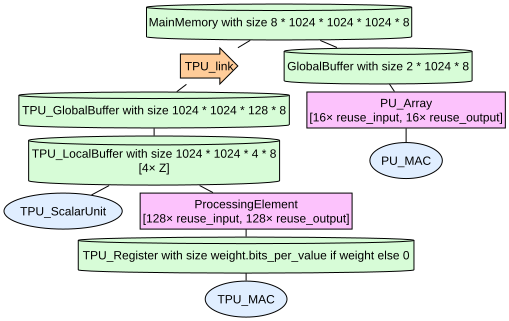

In [19]:
spec.arch

## Workload

GPT-3-like transformer with small ranks for fast mapper evaluation. Includes QKV
projections, attention (QK, softmax, AV), output projection, and FFN layers.
Rank ratios match GPT-3 6.7B scaled down by 64x.

In [ ]:
spec.workload

## Map Workload to Architecture

We map the full workload in a single call. The mapper jointly optimizes across all
einsums and automatically assigns each to the TPU or AiM path through the Fork.

Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 122.30it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s]t [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 101.99it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, ?it/s], 129.07it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK_softmax: 26it [00:00, 104.22it/s]
Generating

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h  [V in TPU_LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [W

Compressing pmappings: 100%|██████████| 10/10 [00:00<00:00, 31.75it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 970.27it/s] 


...

Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 970.37it/s]


Dirty joining uses 99.95% of the pmappings
Filtered 1937 -> 1937 (100.00% kept) pmappings


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 137.66it/s]
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Dirty joining mapping(s) valid & optimal! Returning...


/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usual

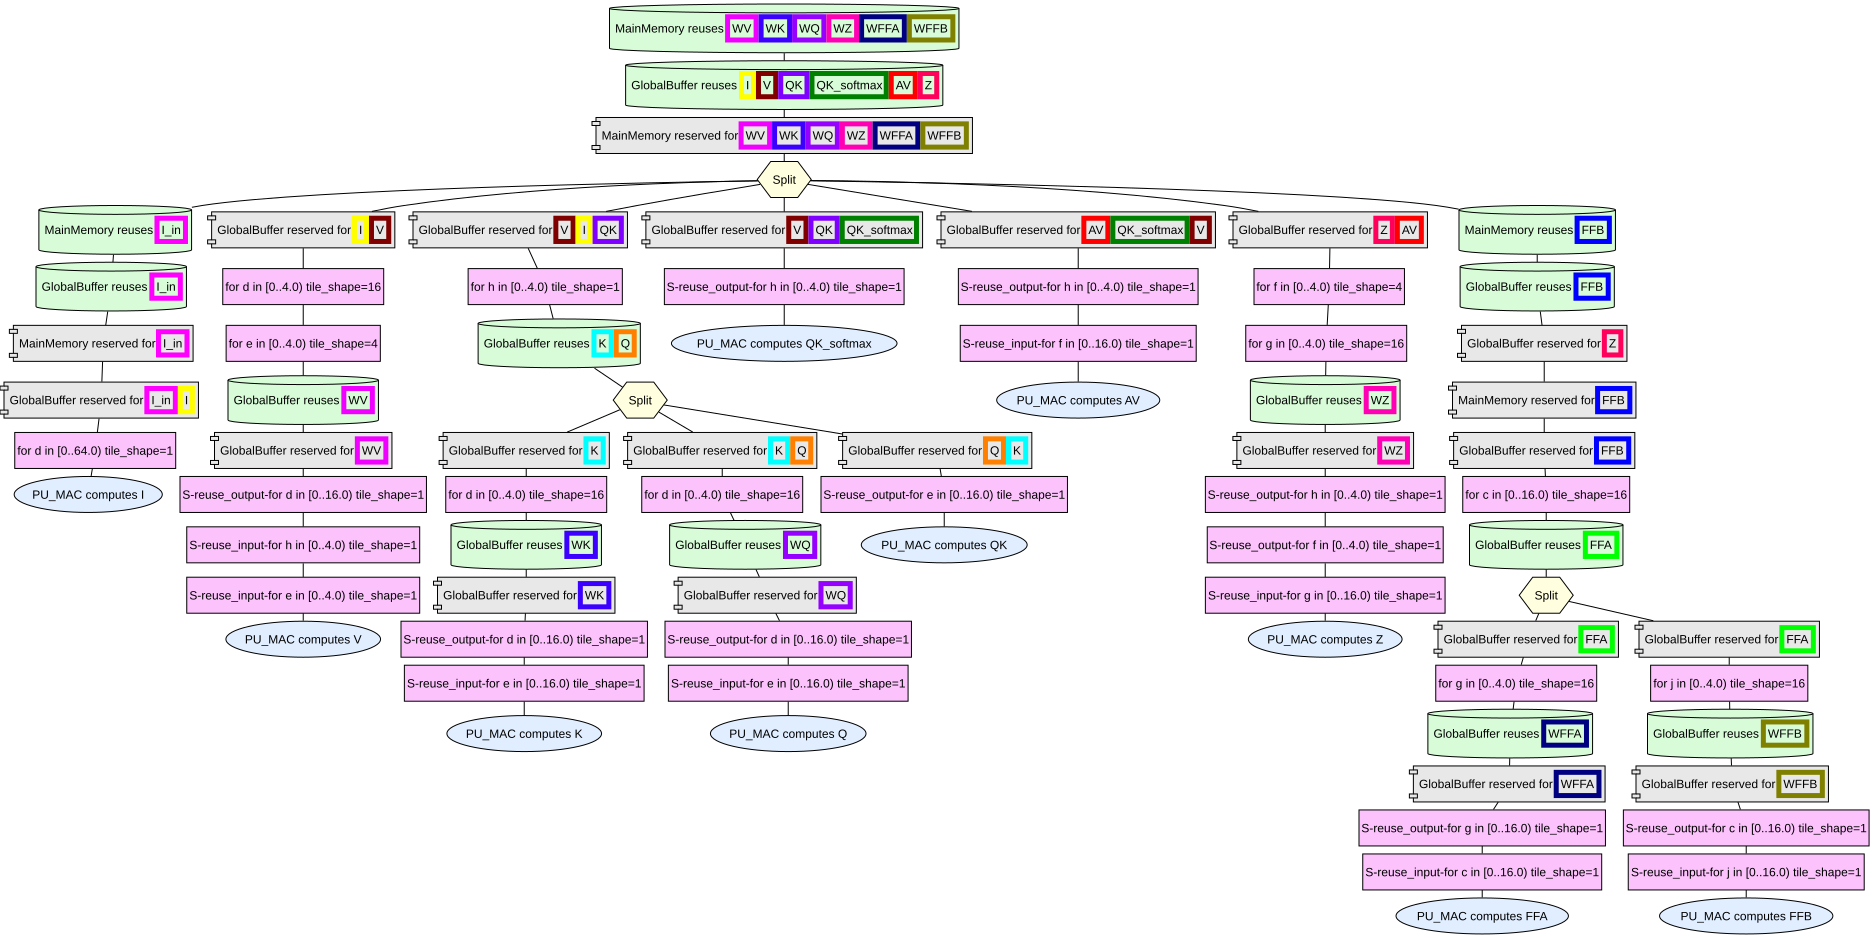

In [ ]:
spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
mapping = spec.map_workload_to_arch()
mapping[0].render()

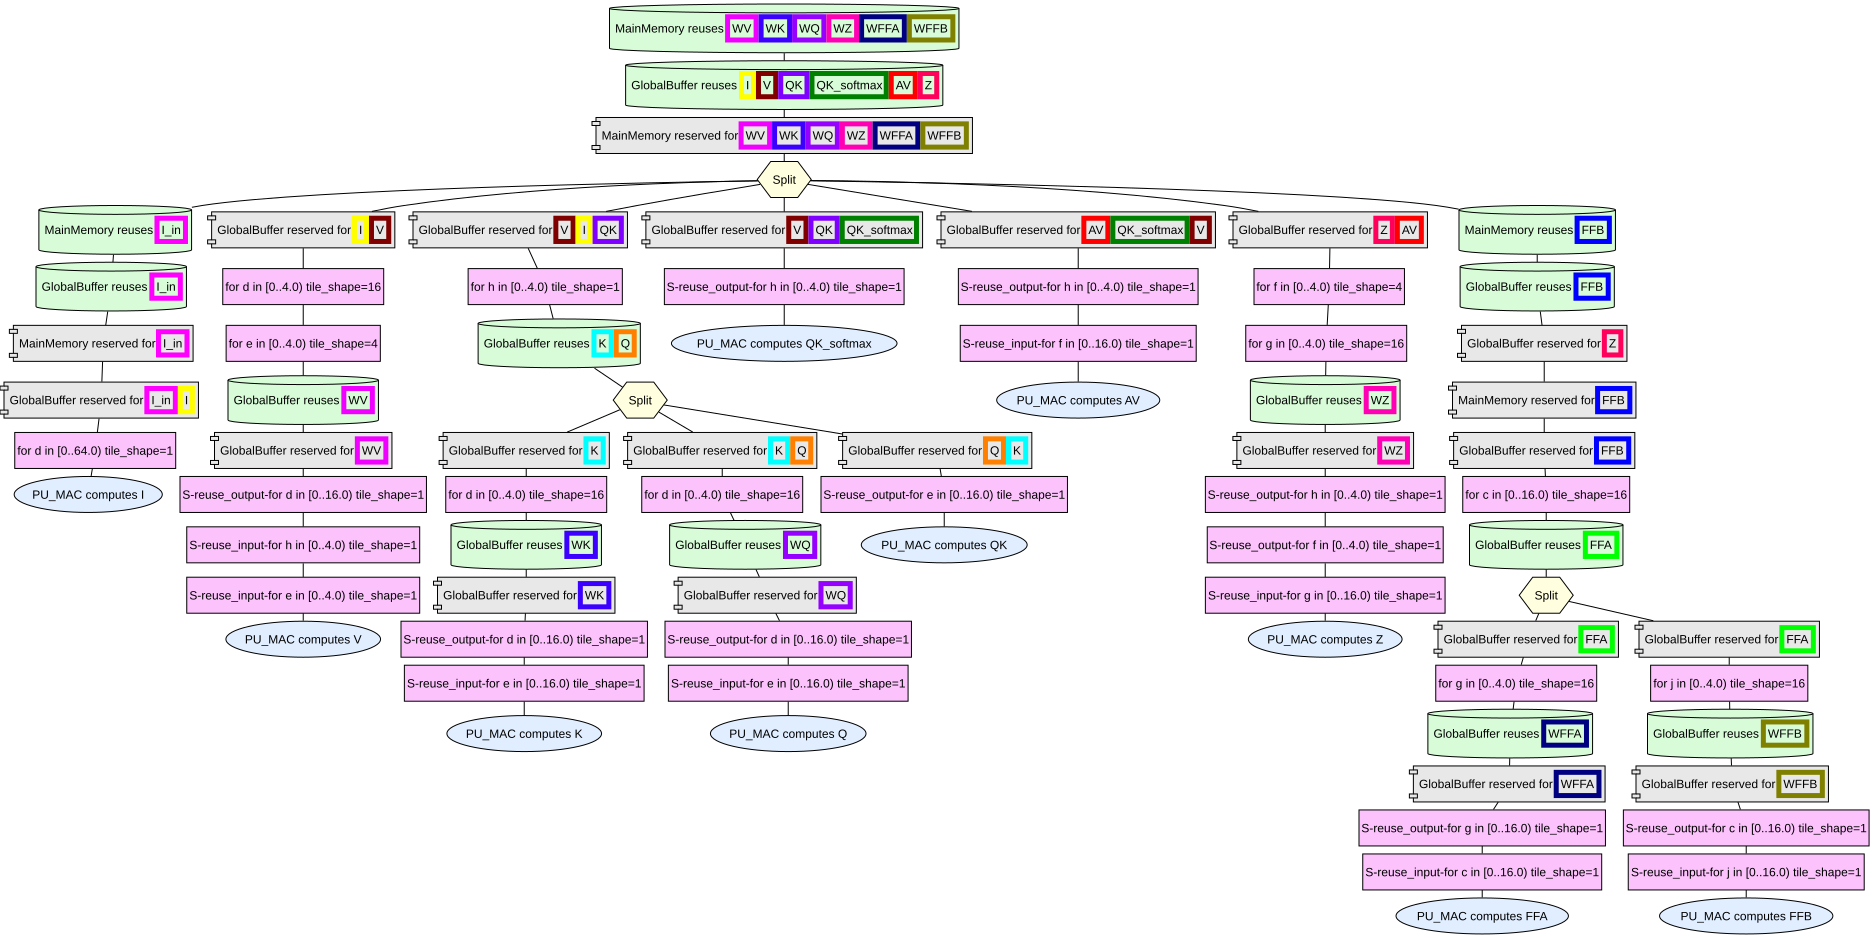

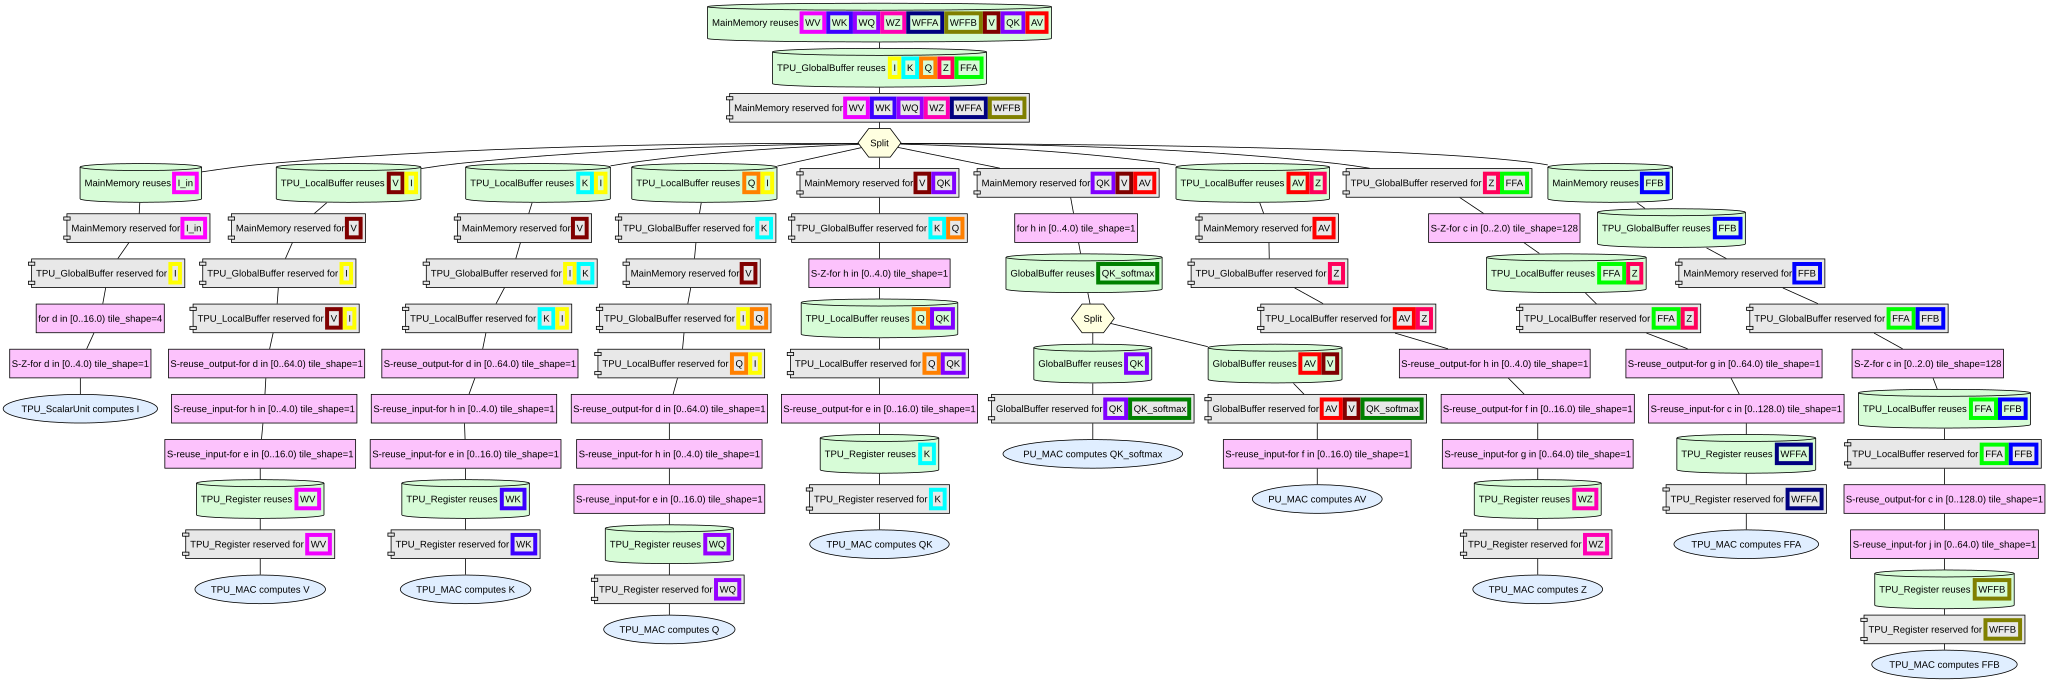

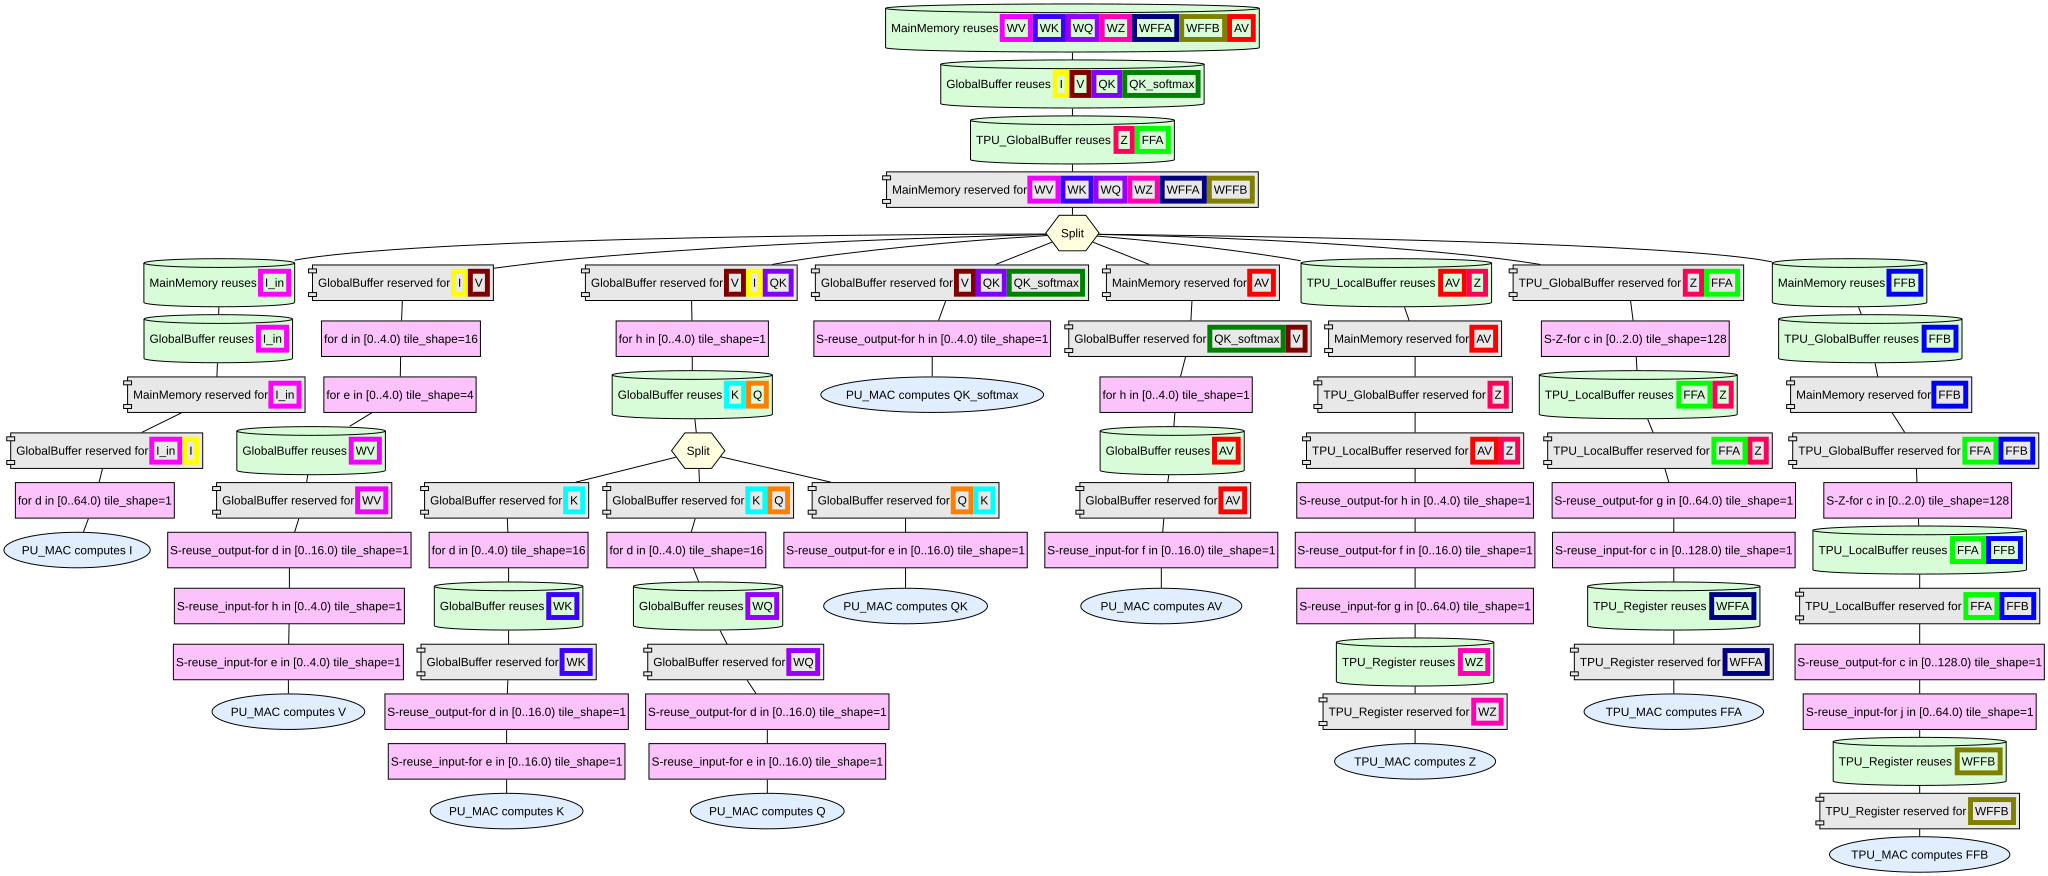

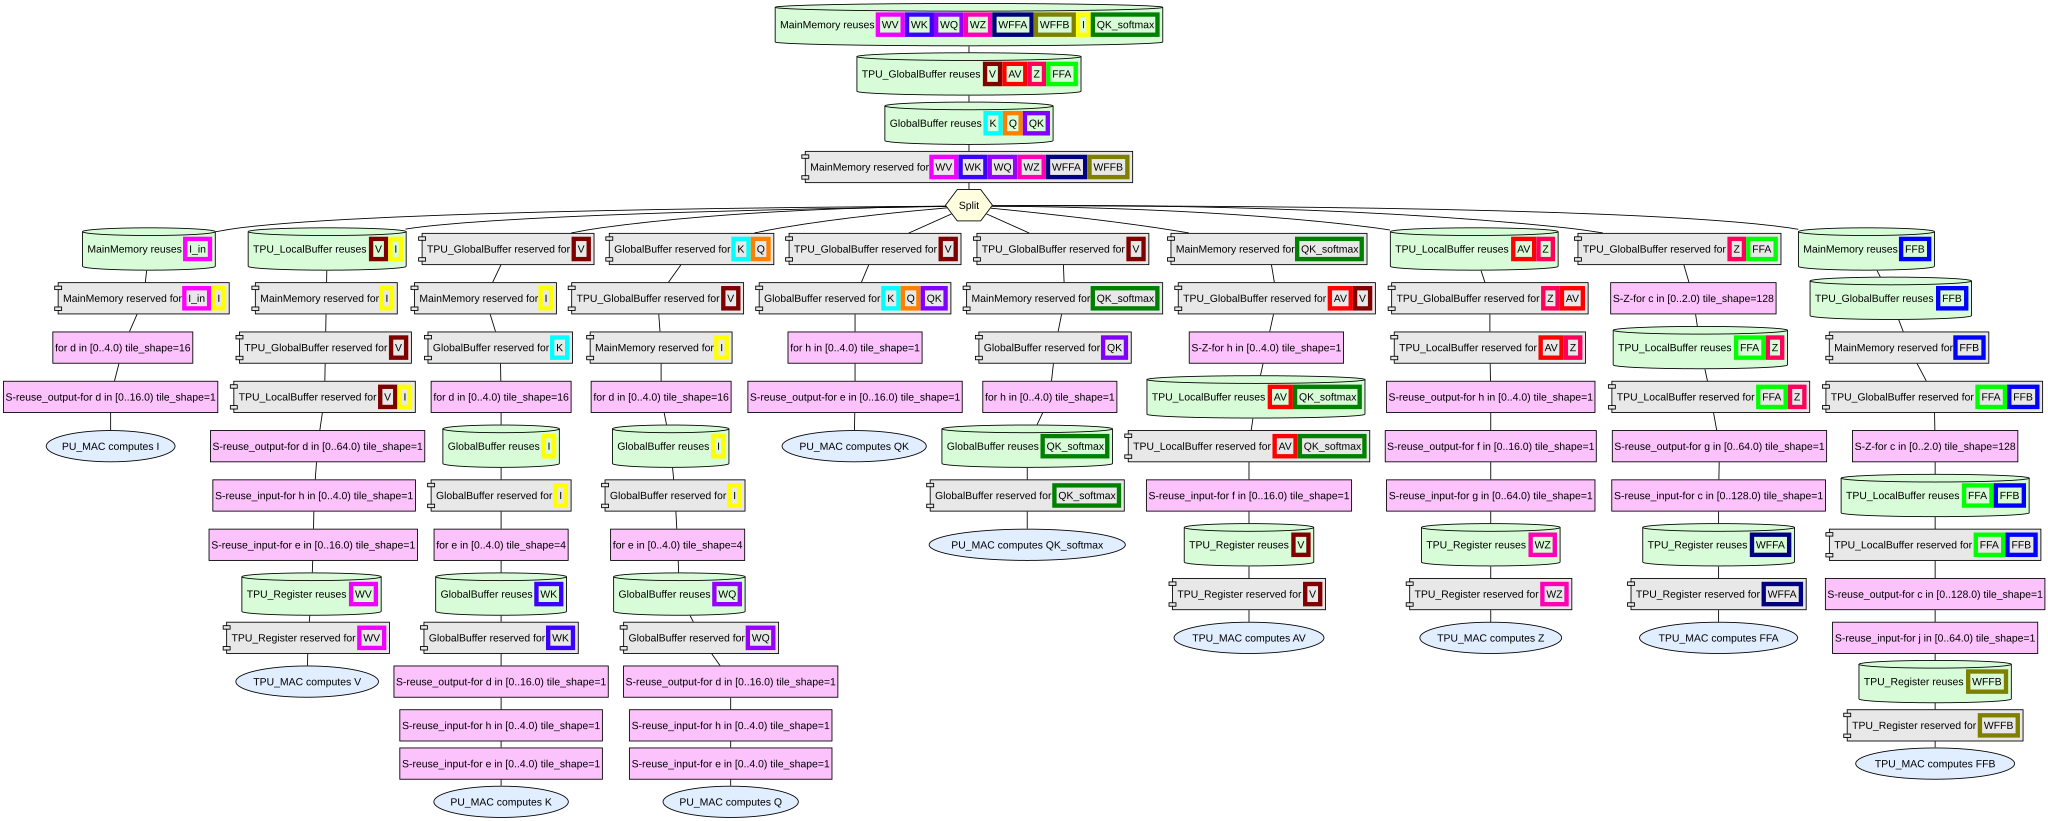

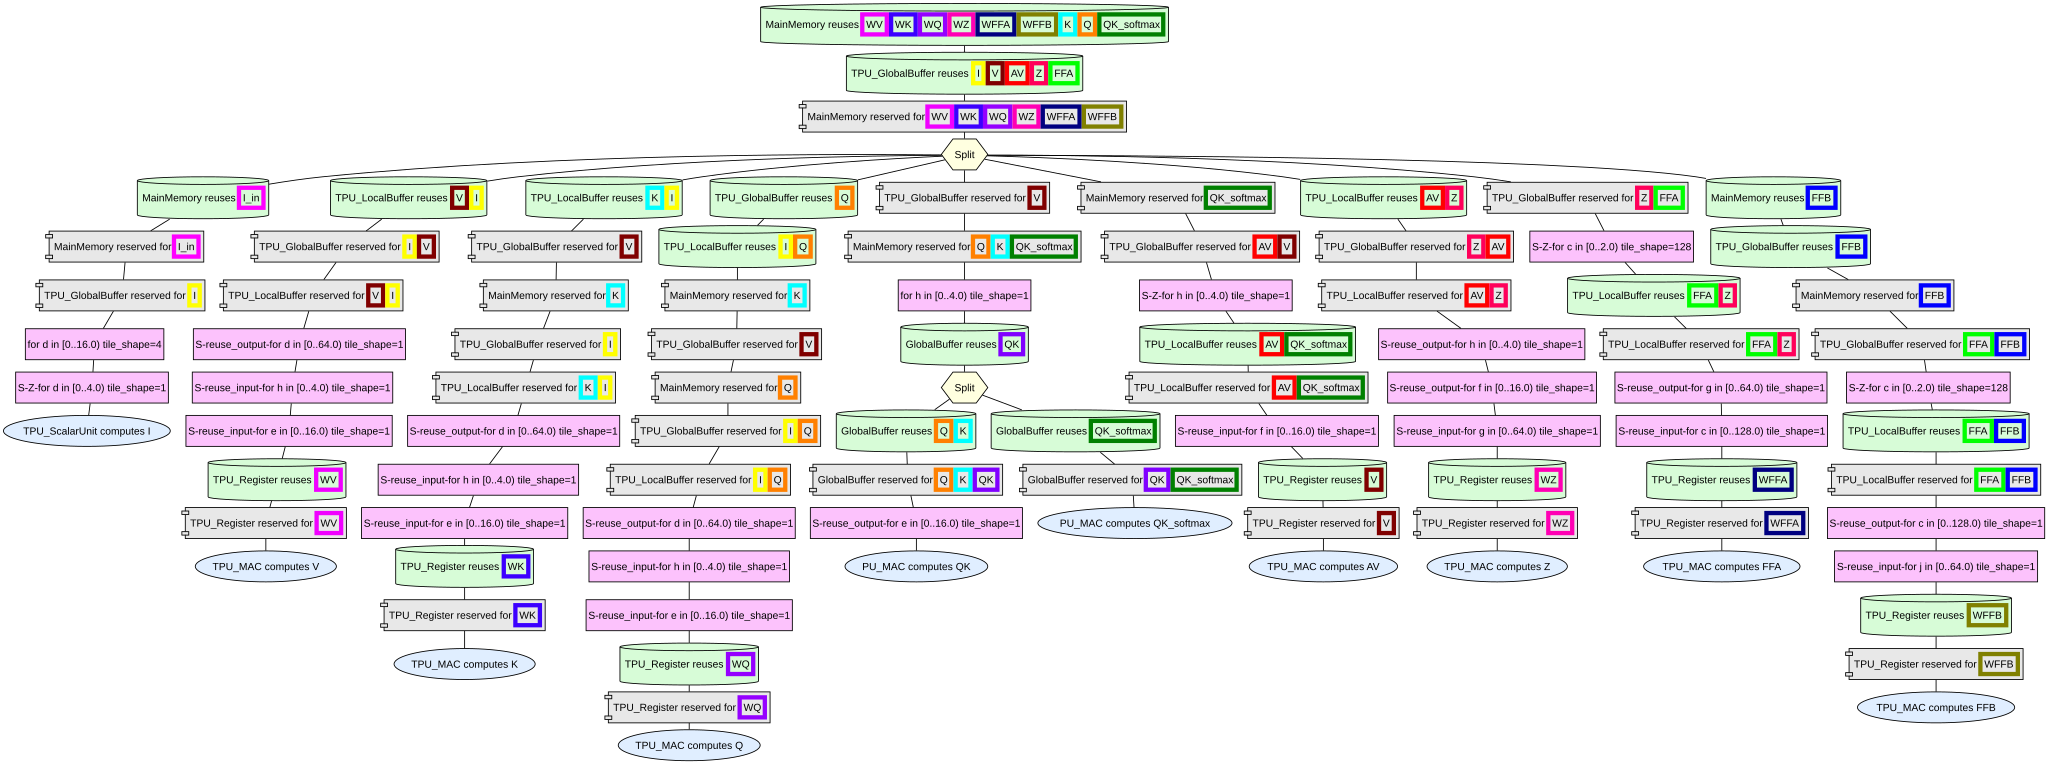

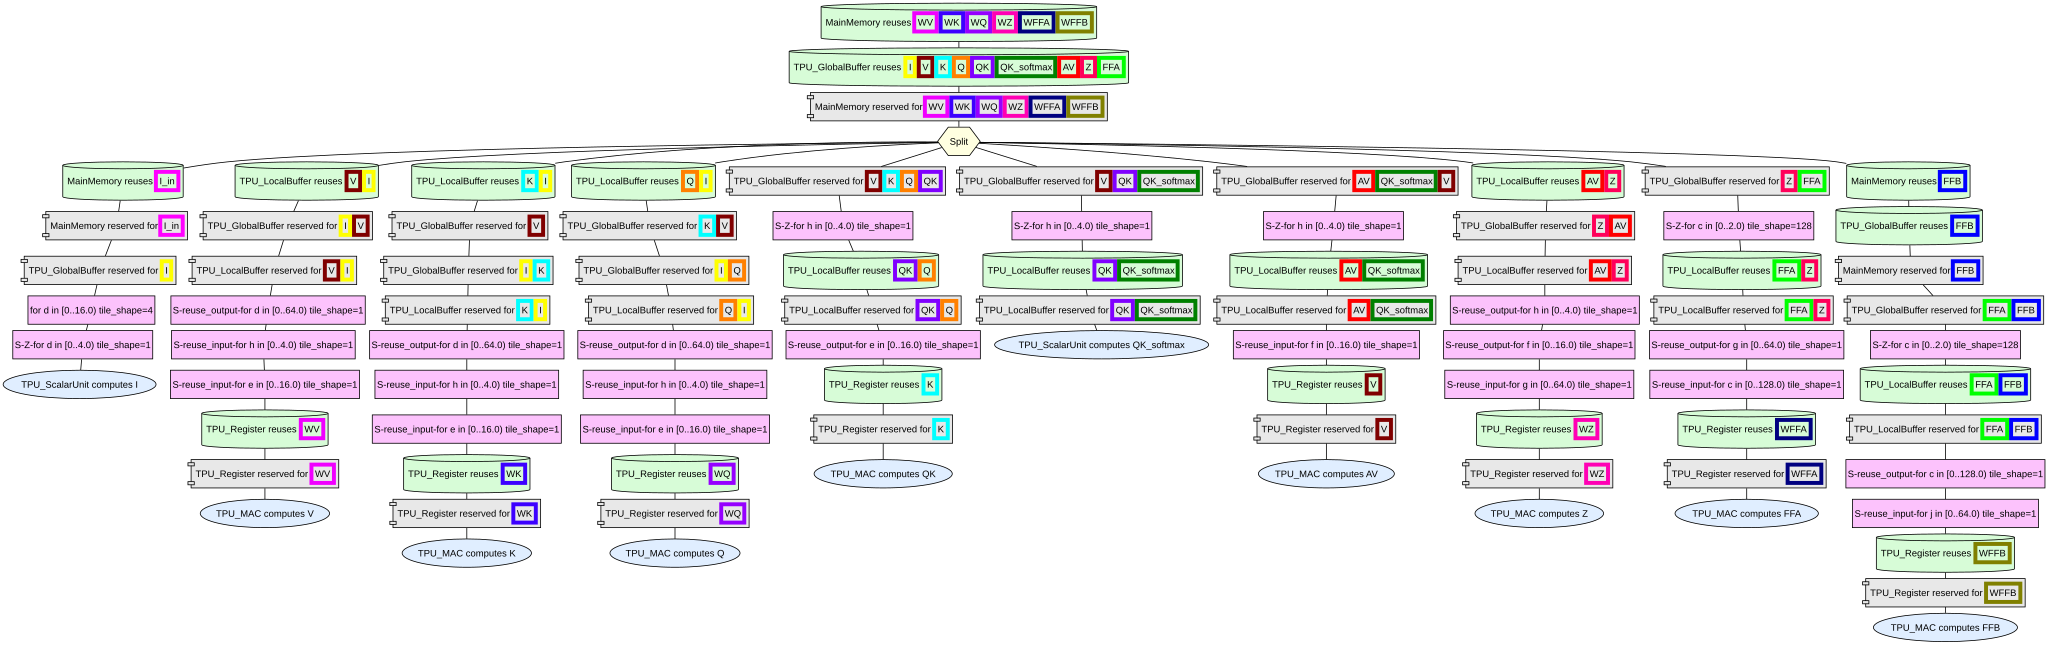

In [ ]:

from IPython.display import display

for i in range(len(mapping)):
    display(mapping[i].render())

## Results

Helper to pick a single result when the mapper returns a Pareto set (list of
optimal trade-offs). We select the point with minimum latency.

### Per-Component Energy and Latency

This shows which hardware components dominate energy and latency. 

In [ ]:
print(mapping.energy())

[5.805920660934161e-06, 5.6359710945185e-06, 5.664987542383218e-06, 5.654556694726316e-06, 5.640312854588991e-06, 5.615505287314285e-06]


EDP IDX: 2


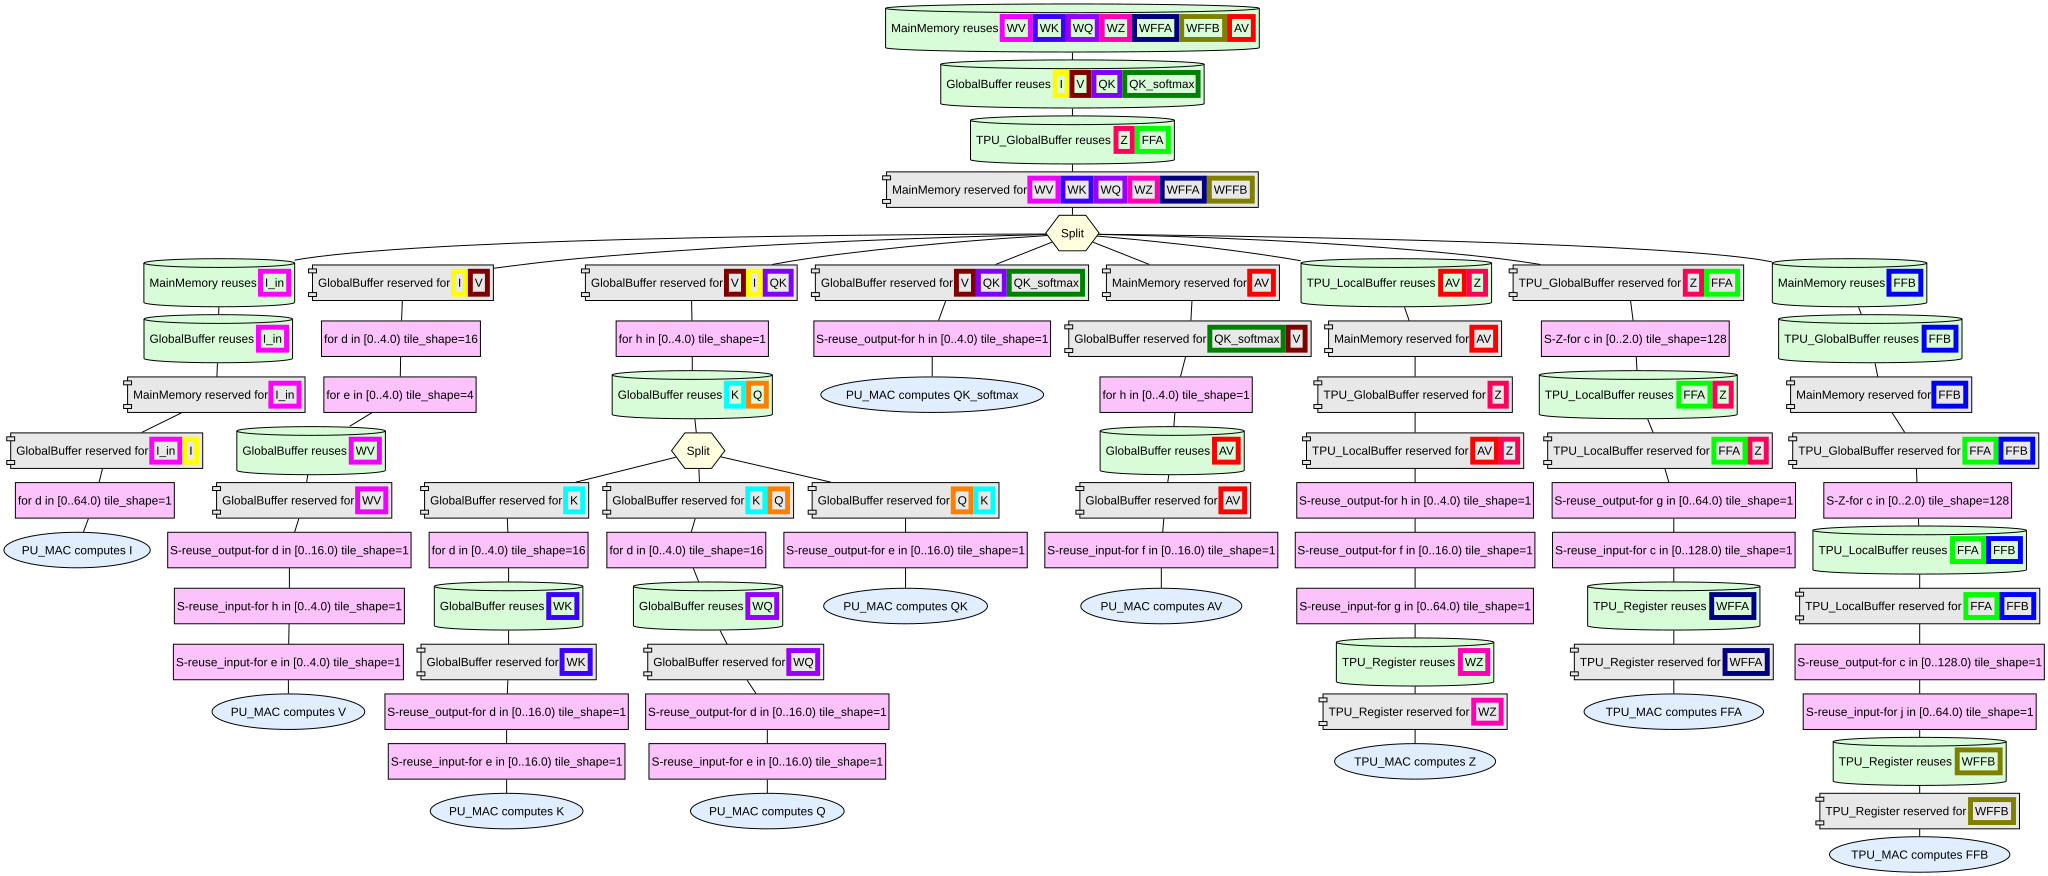

{'GlobalBuffer': np.float64(6.507481558027496e-08), 'MainMemory': np.float64(5.557411718370986e-06), 'TPU_GlobalBuffer': np.float64(3.039232043811069e-08), 'TPU_LocalBuffer': np.float64(7.770112077114297e-09), 'TPU_ScalarUnit': np.float64(0.0), 'TPU_Register': np.float64(0.0), 'TPU_MAC': np.float64(3.096576e-09), 'PU_MAC': np.float64(1.2420000000000003e-09)}
{'GlobalBuffer': np.float64(0.0), 'MainMemory': np.float64(1.6093811225359467e-07), 'PU_MAC': np.float32(2.3632812e-10), 'TPU_GlobalBuffer': np.float32(9.375e-10), 'TPU_ScalarUnit': np.float32(0.0), 'TPU_MAC': np.float32(2.857143e-09), 'TPU_LocalBuffer': np.float64(0.0), 'TPU_Register': np.float64(0.0)}


In [20]:
def pick(val, idx=None):
    """If val is a list (Pareto set), pick element at idx (default: 0)."""
    if isinstance(val, list):
        return val[idx if idx is not None else 0]
    return val


def best_energy_latency_product_idx(result):
    """Choose Pareto index minimizing energy * latency"""
    energies = result.energy()
    latencies = result.latency()
    
    idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
    print("EDP IDX:", idx)
    return idx
    # return None


SELECTED_IDX = best_energy_latency_product_idx(mapping)

tmapping = mapping[SELECTED_IDX]
display(tmapping.render())

energy_by_comp = tmapping.energy(per_component=True)
latency_by_comp = tmapping.latency(per_component=True)

print(energy_by_comp)
print(latency_by_comp)



### Per-Einsum Breakdown

Shows energy and latency for each operation, and which compute path was used.

In [21]:

tmapping_energy = tmapping.energy(per_einsum=True)
tmapping_latency = tmapping.latency(per_einsum=True)

# Determine which path each einsum uses by checking the mapping string
mapping_col = "Total<SEP>mapping"
has_mapping_col = mapping_col in mapping.data.columns


def detect_path(einsum_name, row_index: int):
    """Detect TPU vs AiM from the mapping string for a given einsum."""
    if has_mapping_col:
        row = mapping.data.iloc[min(row_index, len(mapping.data) - 1)]
        mapping_str = str(row.get(mapping_col, ""))
        ein_col = f"{einsum_name}<SEP>mapping"
        if ein_col in mapping.data.columns:
            mapping_str = str(row.get(ein_col, ""))
        if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
            return "TPU"
        if "PU_MAC" in mapping_str:
            return "AiM"
    return "?"


print(f"{'Einsum':<15} {'Path':<6} {'Energy (J)':>14} {'Latency (s)':>14}")
print("-" * 55)


tpu_einsums, aim_einsums = [], []

for ein in tmapping_energy:
    e = pick(tmapping_energy[ein], IDX)
    l = pick(tmapping_latency.get(ein, 0), IDX)
    path = detect_path(ein, IDX)
    if path == "TPU":
        tpu_einsums.append(ein)
    elif path == "AiM":
        aim_einsums.append(ein)
print(f"\nTPU einsums: {', '.join(tpu_einsums) or 'none'}")
print(f"AiM einsums: {', '.join(aim_einsums) or 'none'}")

Einsum          Path       Energy (J)    Latency (s)
-------------------------------------------------------

TPU einsums: Z, FFA, FFB
AiM einsums: I, V, K, Q, QK, QK_softmax, AV


## Visualizations

Energy breakdown by component, stacked by einsum.

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

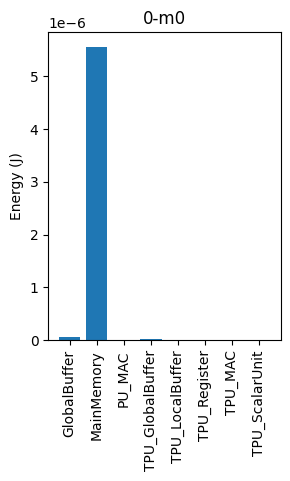

In [ ]:
from accelforge.plotting.mappings import plot_energy_breakdown

plot_energy_breakdown([tmapping], separate_by=["component"])

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

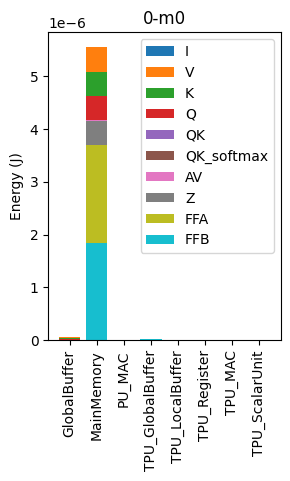

In [ ]:
plot_energy_breakdown([tmapping], separate_by=["component"], stack_by=["einsum"])

(<Figure size 300x400 with 1 Axes>,
 [<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>])

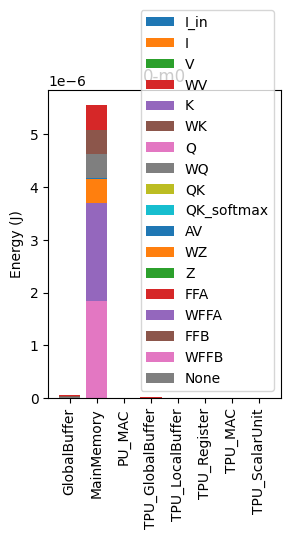

In [ ]:
plot_energy_breakdown([tmapping], separate_by=["component"], stack_by=["tensor"])

## Decode vs Prefill Comparison

During decode (M=1), operations are memory-bound and should favor AiM.
During prefill (M=128), operations become compute-bound and should favor the TPU.
We compare the two phases by re-mapping with different token counts.

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:00<00:00, 29.96it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]], ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 139.92it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 463.89it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]

Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, ?it/s]
Gener

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h  [V in TPU_LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [W

Compressing pmappings: 100%|██████████| 10/10 [00:00<00:00, 43.26it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 1270.44it/s]


...

Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 1991.92it/s]


Dirty joining uses 99.95% of the pmappings
Filtered 1935 -> 1935 (100.00% kept) pmappings


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 129.85it/s]
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Dirty joining mapping(s) valid & optimal! Returning...


/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usual

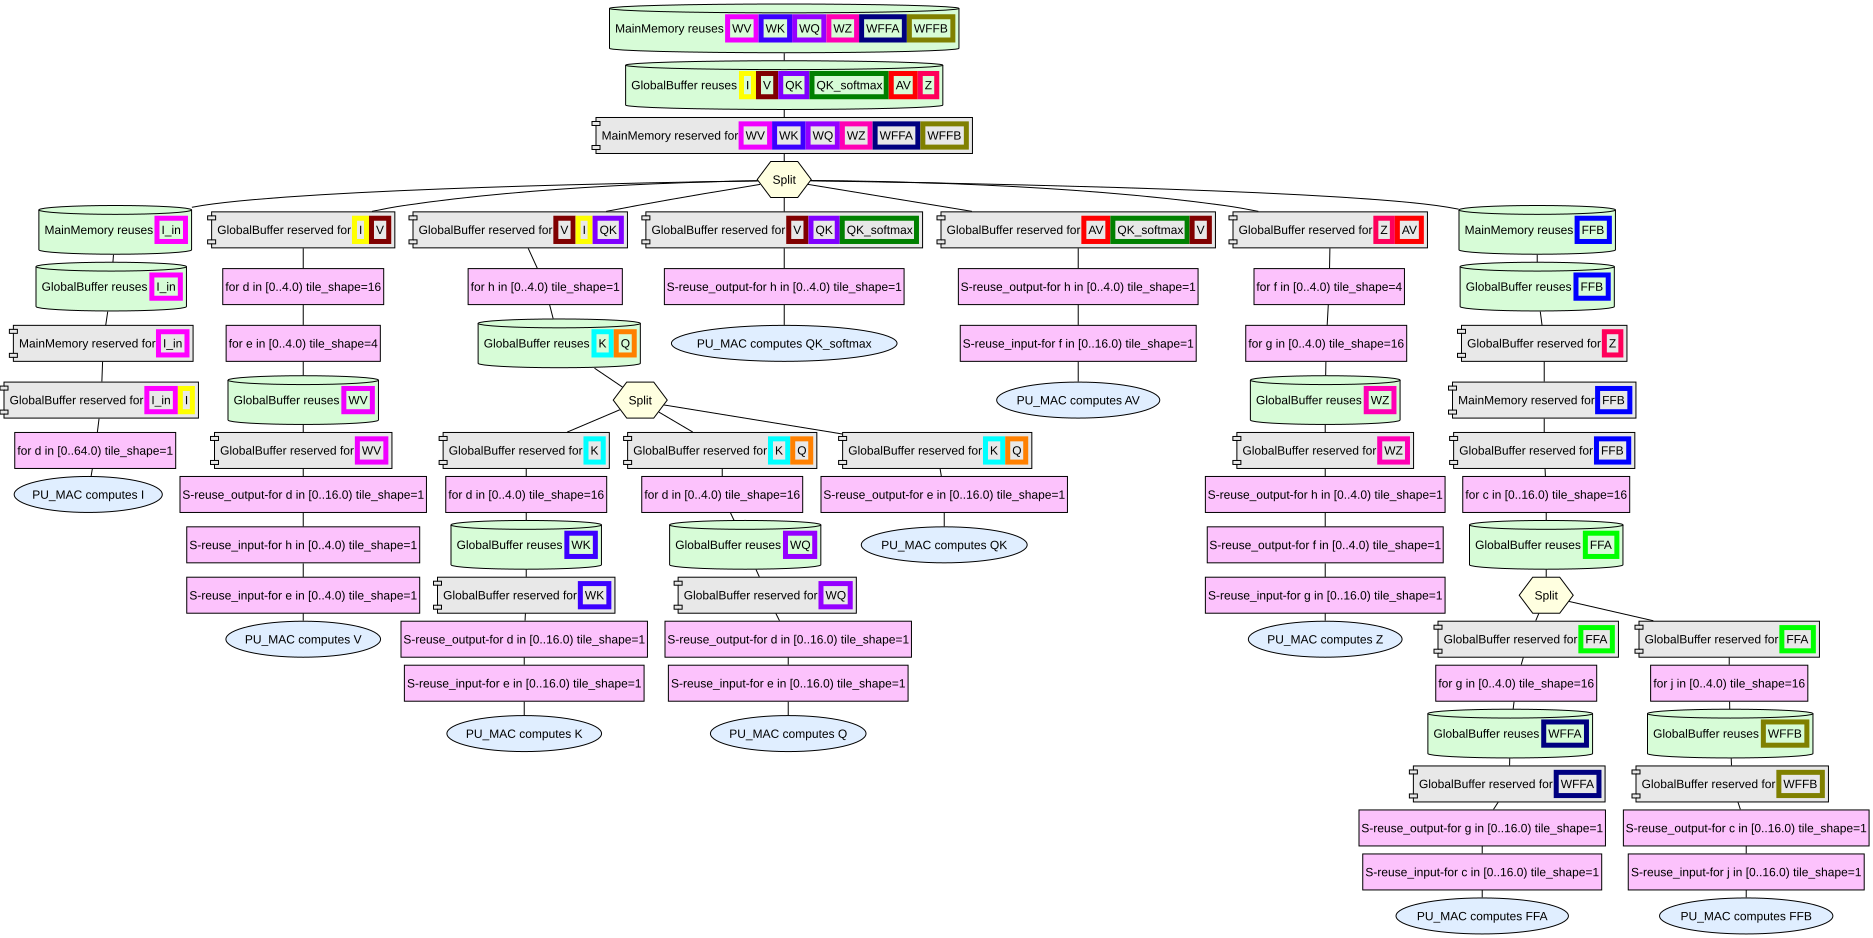

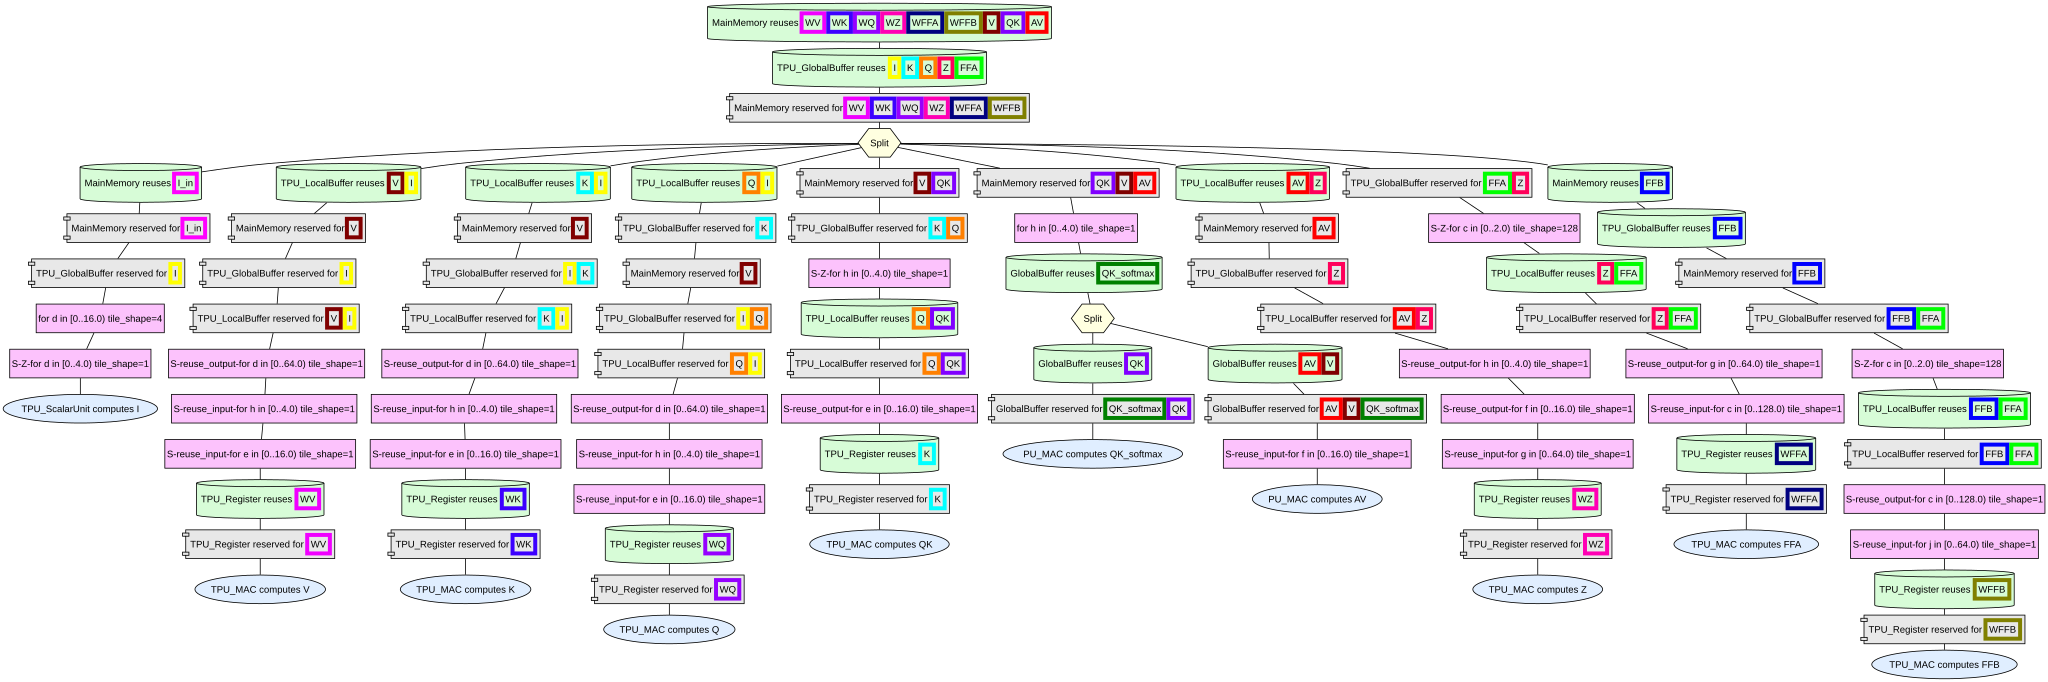

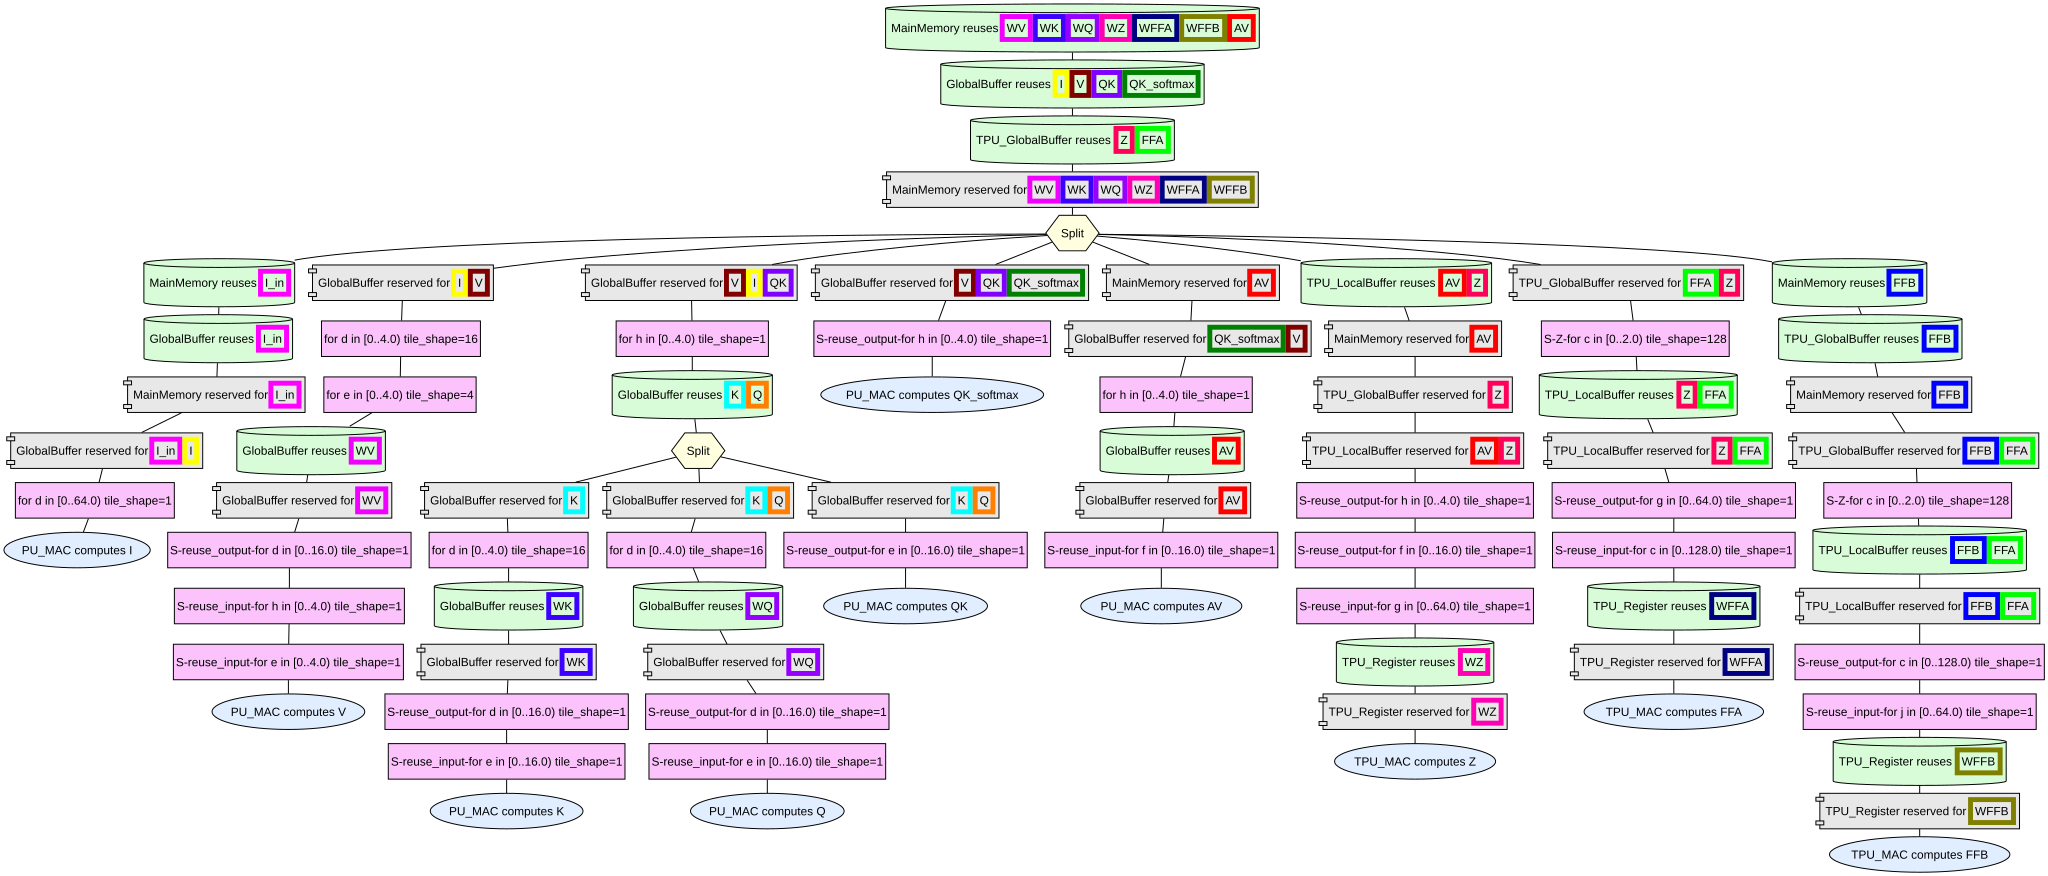

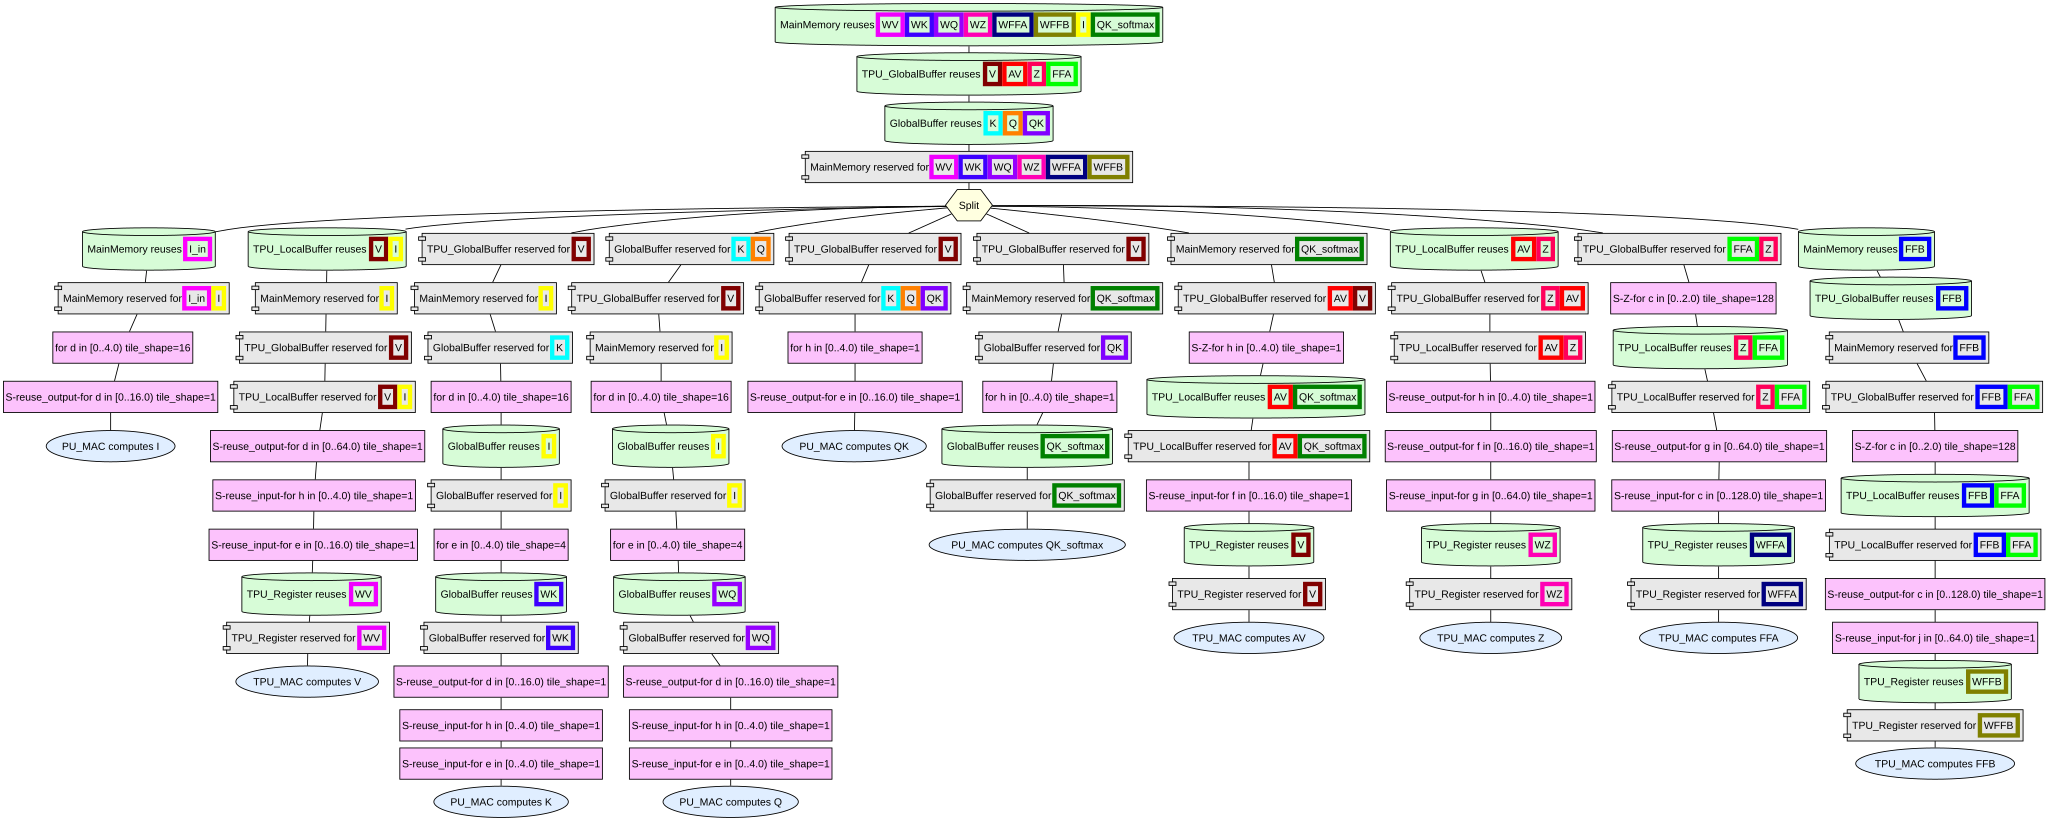

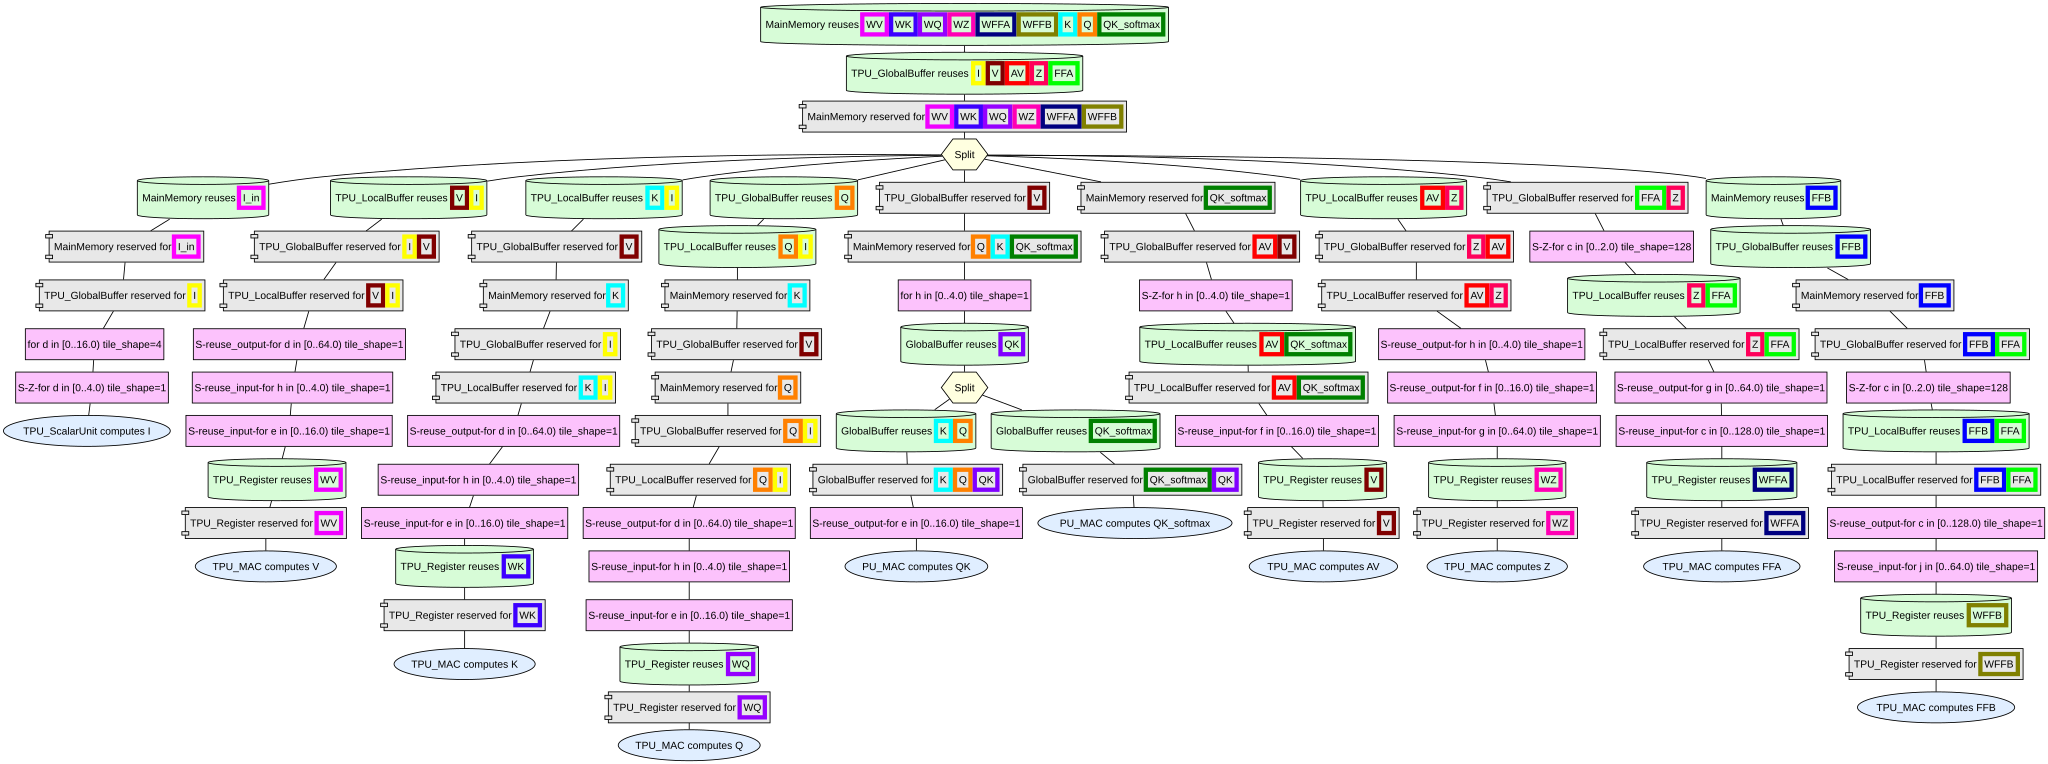

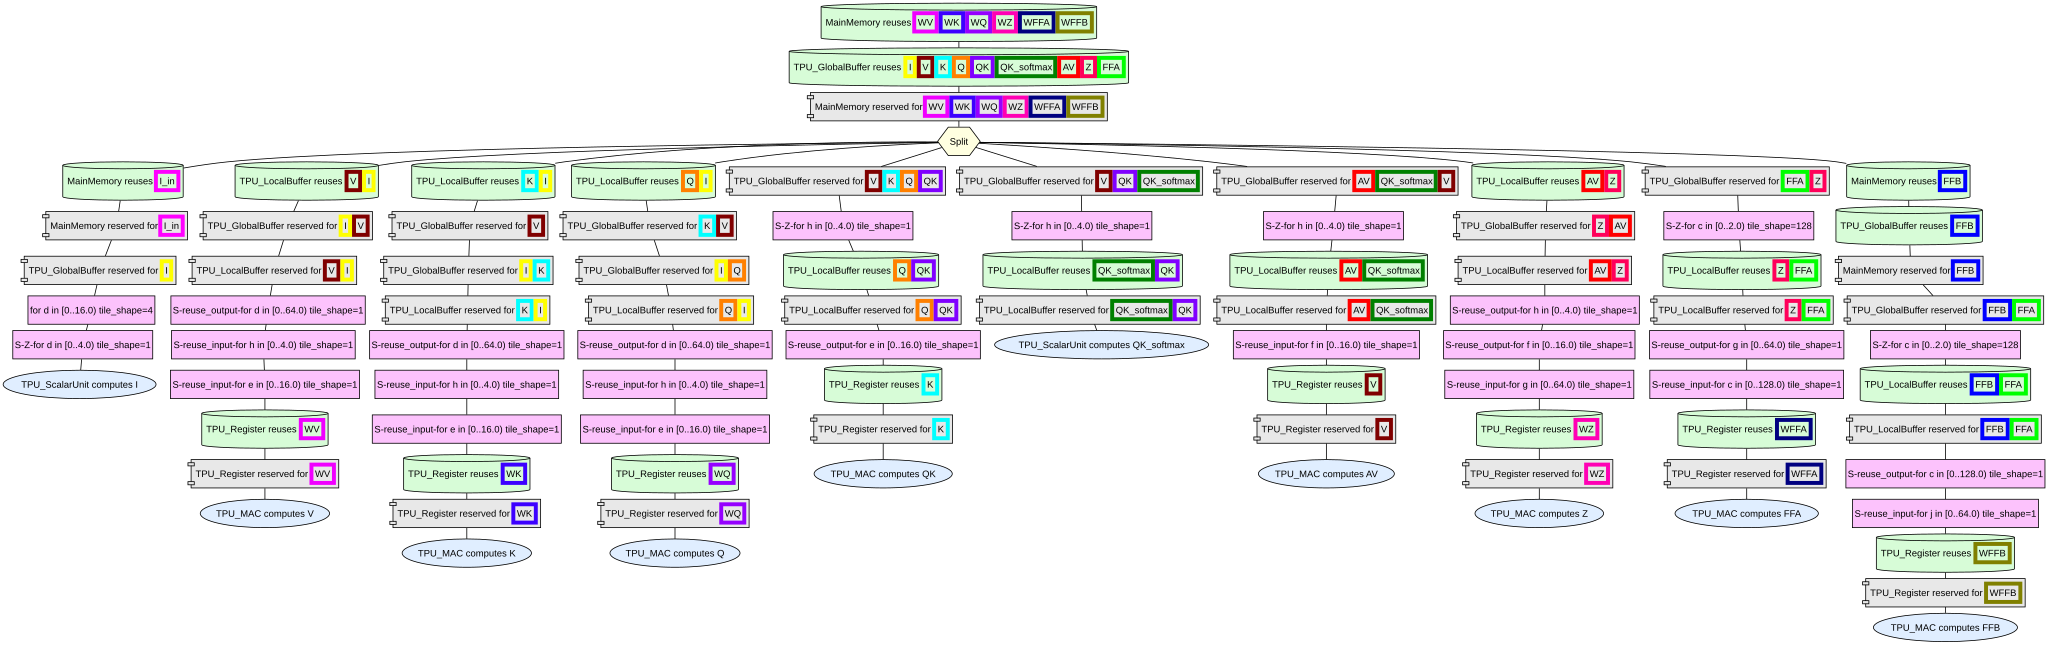

EDP IDX: 2
Decode (M=1): idx=2, energy=5.6650e-06 J, latency=1.6095e-07 s


Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:00<00:00, 29.40it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 89.15it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 247.44it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]0, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]
Genera

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h  [V in TPU_LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [W

Process LokyProcess-14:
Traceback (most recent call last):
  File "/Users/erik/miniconda3/envs/accelforge/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/erik/miniconda3/envs/accelforge/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/erik/miniconda3/envs/accelforge/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py", line 508, in _process_worker
    if time() - _last_memory_leak_check > _MEMORY_LEAK_CHECK_DELAY:
       ^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
results_by_phase = {}

for phase, tokens in [("Decode (M=1)", 1), ("Prefill (M=128)", 128)]:
    phase_params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": tokens}
    phase_spec = af.Spec.from_yaml(
        HYBRID_ARCH, WORKLOAD, jinja_parse_data=phase_params
    )
    phase_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    phase_mapping = phase_spec.map_workload_to_arch()
    for i in range(len(phase_mapping)):
        display(phase_mapping[i].render())
    phase_idx = best_energy_latency_product_idx(phase_mapping)
    selected_phase_idx = 0 if phase_idx is None else phase_idx
    results_by_phase[phase] = {
        "mapping": phase_mapping,
        "selected_idx": selected_phase_idx,
        "energy": pick(phase_mapping.energy(), selected_phase_idx),
        "latency": pick(phase_mapping.latency(), selected_phase_idx),
    }
    print(
        f"{phase}: idx={selected_phase_idx}, "
        f"energy={results_by_phase[phase]['energy']:.4e} J, "
        f"latency={results_by_phase[phase]['latency']:.4e} s"
    )

In [ ]:
phase_mappings = [v["mapping"] for v in results_by_phase.values()]
phase_labels = list(results_by_phase.keys())

plot_energy_breakdown(
    phase_mappings,
    separate_by=["component"],
    stack_by=["einsum"],
    labels=phase_labels,
)

## Per-Einsum: TPU vs AiM Forced Comparison

To understand why the mapper picks one path over the other, we map each einsum
independently to a TPU-only architecture and an AiM-only architecture (both sharing
the same MainMemory). This lets us directly compare energy and latency per-einsum
on each path.